**Setup**

In [1]:
!pip install llama-cpp-python chromadb

In [2]:
import os, random
import numpy as np

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass
except ImportError:
    pass

print('Seeded with', SEED)

Seeded with 42


In [3]:
import os
import json
import re
import sys
import pandas as pd
import numpy as np
import networkx as nx
import chromadb
from pathlib import Path
from collections import Counter, defaultdict
from chromadb.utils import embedding_functions
from sentence_transformers import SentenceTransformer, util
from llama_cpp import Llama, LlamaGrammar

# --- Path configuration: change only this block when migrating ---
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # UPDATE THIS to your actual project path on Google Drive
    PROJECT_ROOT = Path('/content/drive/MyDrive/SRH/Thesis')
else:
    PROJECT_ROOT = Path('..').resolve()

# Derived paths (no need to edit these)
DATA_DIR       = PROJECT_ROOT / 'data'
CICIDS_DIR     = DATA_DIR / 'cicids'
ATTCK_DIR      = DATA_DIR / 'attck'
CHROMA_DIR     = DATA_DIR / 'chroma'
RESULTS_DIR    = PROJECT_ROOT / 'results' / 'cicids' / 'mistral-nemo-12b'
PROCESSED_DIR  = DATA_DIR / 'results'
MODELS_DIR     = PROJECT_ROOT / 'models'
MODEL_FILENAME = 'Mistral-Nemo-Instruct-2407-Q5_K_M.gguf'
MODEL_PATH     = str(MODELS_DIR / MODEL_FILENAME)

# Model config
MODEL_REGISTRY = {
    'mistral-nemo-12b': {
        'file': MODEL_FILENAME,
        'repo': 'bartowski/Mistral-Nemo-Instruct-2407-GGUF',
        'fmt': 'mistral'
    },
}
ACTIVE_MODEL = 'mistral-nemo-12b'
_cfg = MODEL_REGISTRY[ACTIVE_MODEL]
MODEL_FMT = _cfg['fmt']
RANDOM_SEED = 42

# Verify paths
if not os.path.isfile(MODEL_PATH):
    print(f'WARNING: Model file not found at {MODEL_PATH}')
    print('Download from: https://huggingface.co/bartowski/Mistral-Nemo-Instruct-2407-GGUF')
else:
    print(f'Active model: {ACTIVE_MODEL}  ->  {MODEL_PATH}')
print(f'Project root: {PROJECT_ROOT}')
print(f'Results dir:  {RESULTS_DIR}')

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHROMA_DIR.mkdir(parents=True, exist_ok=True)

if not (ATTCK_DIR / 'enterprise-attack.json').exists():
    print(f'WARNING: ATT&CK data not found at {ATTCK_DIR / "enterprise-attack.json"}')
    print('Download from: https://github.com/mitre/cti/')


Active model: mistral-nemo-12b  ->  /home/amenadiel/RAG-Based-Incident-Reporting-on-SIEM-Log-Streams/models/Mistral-Nemo-Instruct-2407-Q5_K_M.gguf
Project root: /home/amenadiel/RAG-Based-Incident-Reporting-on-SIEM-Log-Streams
Results dir:  /home/amenadiel/RAG-Based-Incident-Reporting-on-SIEM-Log-Streams/results/cicids/mistral-nemo-12b


**1. Load and sample CIC-IDS-2017**

In [4]:
if not CICIDS_DIR.exists():
    raise FileNotFoundError(f'CIC-IDS data directory not found: {CICIDS_DIR}')

csv_files = [f for f in os.listdir(CICIDS_DIR) if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError(f'No CSV files found in {CICIDS_DIR}')

# drop Monday (benign-only) and Wednesday (DoS-only) for balance
csv_files_filtered = [f for f in csv_files if 'Monday' not in f and 'Wednesday' not in f]
print(f'Found {len(csv_files)} CSV files, using {len(csv_files_filtered)} after filtering')
for f in csv_files_filtered:
    print(f'  {f}')


Found 8 CSV files, using 6 after filtering
  Tuesday-WorkingHours.pcap_ISCX.csv
  Friday-WorkingHours-Morning.pcap_ISCX.csv
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv


In [5]:
dfs = []
failed_files = []
for f in csv_files_filtered:
    fpath = os.path.join(CICIDS_DIR, f)
    try:
        df_temp = pd.read_csv(fpath, encoding='utf-8')
        df_temp['Source_File'] = f
        dfs.append(df_temp)
    except Exception as e:
        failed_files.append((f, str(e)))
        print(f'WARNING: Could not read {f}: {e}')

if not dfs:
    raise RuntimeError(f'No CSV files could be read. Failed: {failed_files}')

df_combined = pd.concat(dfs, ignore_index=True)
print(f'{len(df_combined)} rows loaded from {len(dfs)} file(s)')
if failed_files:
    print(f'Skipped {len(failed_files)} file(s): {[f for f, _ in failed_files]}')


1608122 rows loaded from 6 file(s)


In [6]:
# clean label encoding
df_combined[' Label'] = df_combined[' Label'].str.replace('\ufffd', '-', regex=False)
df_combined[' Label'] = df_combined[' Label'].str.replace(r'\s*-\s*', ' - ', regex=True).str.strip()
print(df_combined[' Label'].value_counts())


 Label
BENIGN                        1303148
PortScan                       158930
DDoS                           128027
FTP - Patator                    7938
SSH - Patator                    5897
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Name: count, dtype: int64


In [7]:
# up to 2000 samples per label
sampled_dfs = []
for label in df_combined[' Label'].unique():
    label_df = df_combined[df_combined[' Label'] == label]
    sampled_dfs.append(label_df.sample(n=min(2000, len(label_df)), random_state=42))
df_sampled = pd.concat(sampled_dfs, ignore_index=True)
print(len(df_sampled), 'sampled')


14182 sampled


In [8]:
columns_to_keep = [
    ' Label', ' Destination Port', ' Flow Duration', ' Total Fwd Packets',
    ' Total Backward Packets', ' SYN Flag Count', ' RST Flag Count', 'FIN Flag Count',
    'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Down/Up Ratio',
    ' Average Packet Size', ' Packet Length Std', 'Active Mean', 'Idle Mean']
df_filtered = df_sampled[columns_to_keep].copy()
print(df_filtered.shape)

(14182, 16)


**2. ATT&CK reference and ground-truth mapping**

In [9]:
# load ATT&CK techniques keyed by MITRE ID
if not (ATTCK_DIR / 'enterprise-attack.json').exists():
    raise FileNotFoundError(f'ATT&CK data not found at {ATTCK_DIR / "enterprise-attack.json"}')

with open(ATTCK_DIR / 'enterprise-attack.json', 'r', encoding='utf-8') as f:
    bundle = json.load(f)

attck_techniques = {}
for obj in bundle.get('objects', []):
    if obj.get('type') != 'attack-pattern' or obj.get('revoked') or obj.get('x_mitre_deprecated'):
        continue
    tid = next((r.get('external_id') for r in obj.get('external_references', [])
                if r.get('source_name') == 'mitre-attack'), None)
    if not tid:
        continue
    tactics = [p.get('phase_name','').capitalize() for p in obj.get('kill_chain_phases', []) if p.get('phase_name')]
    attck_techniques[tid] = {'name': obj.get('name','Unknown'), 'tactics': tactics,
                             'description': obj.get('description','')}
print(f'{len(attck_techniques)} techniques loaded')


691 techniques loaded


In [10]:
# CIC-IDS-2017 label to MITRE ATT&CK technique (ground-truth mapping):
#   FTP/SSH-Patator            T1110.001  Brute Force: Password Guessing
#   DDoS                       T1498.001  Network DoS: Direct Network Flood
#   PortScan                   T1046      Network Service Discovery
#   Bot                        T1071.001  Application Layer Protocol: Web Protocols
#   Web Attack - Brute Force   T1110.001  HTTP login guessing
#   Web Attack - XSS           T1059.007  Command and Scripting Interpreter: JavaScript
#   Infiltration               T1203      Exploitation for Client Execution
#   Web Attack - SQL Injection T1190      Exploit Public-Facing Application
label_to_technique = {
    'BENIGN': None,
    'FTP - Patator': 'T1110.001',
    'SSH - Patator': 'T1110.001',
    'DDoS': 'T1498.001',
    'PortScan': 'T1046',
    'Bot': 'T1071.001',
    'Web Attack - Brute Force': 'T1110.001',
    'Web Attack - XSS': 'T1059.007',
    'Infiltration': 'T1203',
    'Web Attack - Sql Injection': 'T1190'}


In [11]:
df_sampled['Technique'] = df_sampled[' Label'].map(label_to_technique)


In [12]:
def get_tactics(tech_id):
    if pd.isna(tech_id):
        return None
    return attck_techniques.get(tech_id, {}).get('tactics', None)

df_sampled['Tactics'] = df_sampled['Technique'].apply(get_tactics)
print('unmapped:', df_sampled['Technique'].isna().sum())


unmapped: 2000


**3. Flow-to-text descriptors**

In [13]:
def get_port_service(port: int) -> str:
    port_map = {
        20: "FTP-Data", 21: "FTP", 22: "SSH", 23: "Telnet", 25: "SMTP",
        53: "DNS", 67: "DHCP-Server", 68: "DHCP-Client", 69: "TFTP",
        80: "HTTP", 110: "POP3", 119: "NNTP", 123: "NTP", 135: "RPC",
        137: "NetBIOS-Name", 138: "NetBIOS-Datagram", 139: "NetBIOS-Session",
        143: "IMAP", 161: "SNMP", 162: "SNMP-Trap", 179: "BGP",
        389: "LDAP", 443: "HTTPS", 445: "SMB", 465: "SMTPS",
        514: "Syslog", 587: "SMTP-Submission", 636: "LDAPS",
        993: "IMAPS", 995: "POP3S", 1080: "SOCKS-Proxy", 1433: "MSSQL",
        1521: "OracleDB", 1723: "PPTP", 2049: "NFS", 3306: "MySQL",
        3389: "RDP", 5432: "PostgreSQL", 5900: "VNC", 6379: "Redis",
        8080: "HTTP-Alt", 8443: "HTTPS-Alt", 9000: "Dev-Services",
        9200: "Elasticsearch", 27017: "MongoDB"}
    return port_map.get(port, f"unknown-port-{port}")

# Flow-statistic descriptors: translate numeric features into neutral text.
# They describe magnitude/shape only and never name an attack type.
def describe_duration(dur: float) -> str:
    # Flow Duration is in microseconds; convert to seconds before bucketing.
    sec = dur / 1_000_000.0
    if sec < 1.0:     return "sub-second connection"
    elif sec < 10.0:  return "short-lived connection"
    elif sec < 60.0:  return "sustained connection"
    elif sec < 300.0: return "persistent connection"
    else:             return "long-duration connection"

def describe_volume(fwd: int, bwd: int) -> str:
    total = fwd + bwd
    if total < 10:     return "very low packet count"
    elif total < 100:  return "low packet count"
    elif total < 1000: return "moderate packet count"
    else:              return "high packet count"

def describe_flags(syn: int, rst: int, fin: int) -> str:
    if syn > 50 and rst == 0 and fin == 0:
        return "many SYN with no RST or FIN (incomplete handshakes)"
    elif rst > syn * 0.4:
        return "frequent RST relative to SYN (many resets)"
    elif fin > 0 and rst == 0:
        return "connections closed with FIN"
    else:
        return "mixed TCP control flags"

def describe_asymmetry(ratio: float) -> str:
    if ratio < 0.3:
        return "strongly outbound-dominant traffic"
    elif ratio > 3.0:
        return "strongly inbound-dominant traffic"
    else:
        return "roughly balanced bidirectional traffic"

def describe_iat(iat: float) -> str:
    # Flow IAT Mean is in microseconds; convert to seconds before bucketing.
    sec = iat / 1_000_000.0
    if sec < 0.01:  return "sub-10ms inter-arrival timing"
    elif sec < 0.1: return "rapid inter-arrival timing"
    elif sec < 1.0: return "sub-second inter-arrival timing"
    else:           return "multi-second inter-arrival gaps"

def describe_session(act: float, idle: float) -> str:
    if act > 0 and idle < act * 0.1:
        return "continuously active with little idle time"
    elif idle > act * 2:
        return "mostly idle with short active bursts"
    else:
        return "alternating active and idle periods"

def describe_payload(avg: float, std: float) -> str:
    if avg < 100 and std < 50:     return "small uniform packets"
    elif avg < 100 and std >= 50:  return "small variable-size packets"
    elif avg > 1000 and std < 200: return "large uniform packets"
    elif avg > 1000 and std >= 200:return "large variable-size packets"
    else:                          return "moderate-size packets"

def describe_rate(pps: float, bps: float) -> str:
    if pps > 1000 and bps > 1_000_000:
        return "very high packet rate and very high byte rate"
    elif pps > 1000:
        return "very high packet rate with low byte volume"
    elif bps > 1_000_000:
        return "high byte rate with moderate packet count"
    elif pps < 1 and bps < 100:
        return "very low packet and byte rate"
    else:
        return "moderate packet and byte rate"

In [14]:
def build_semantic_alert(row: pd.Series) -> str:
    g = lambda k, t, d: t(row[k]) if pd.notna(row[k]) else d
    port   = g(' Destination Port', int, 0)
    dur    = g(' Flow Duration', float, 0.0)
    fwd    = g(' Total Fwd Packets', int, 0)
    bwd    = g(' Total Backward Packets', int, 0)
    syn    = g(' SYN Flag Count', int, 0)
    rst    = g(' RST Flag Count', int, 0)
    fin    = g('FIN Flag Count', int, 0)
    pps    = g(' Flow Packets/s', float, 0.0)
    bps    = g('Flow Bytes/s', float, 0.0)
    iat    = g(' Flow IAT Mean', float, 0.0)
    asym   = g(' Down/Up Ratio', float, 0.0)
    avg_sz = g(' Average Packet Size', float, 0.0)
    std_sz = g(' Packet Length Std', float, 0.0)
    act    = g('Active Mean', float, 0.0)
    idle   = g('Idle Mean', float, 0.0)

    return (
        f"Network flow targeting {get_port_service(port)} on port {port}. "
        f"Connection profile: {describe_duration(dur)}. "
        f"Traffic exchange: {describe_volume(fwd, bwd)}, with {fwd} outbound and {bwd} inbound packets. "
        f"TCP behavior: {describe_flags(syn, rst, fin)}. "
        f"Timing pattern: {describe_iat(iat)}. "
        f"Traffic rate: {describe_rate(pps, bps)}. "
        f"Directionality: {describe_asymmetry(asym)}. "
        f"Session rhythm: {describe_session(act, idle)}. "
        f"Payload characteristics: {describe_payload(avg_sz, std_sz)}.")


In [15]:
df_filtered['alert_text'] = df_filtered.apply(build_semantic_alert, axis=1)
alert_texts = df_filtered['alert_text'].tolist()
print(len(alert_texts), 'alerts')


14182 alerts


In [16]:
# Community-level context from flow statistics only (no labels): port diversity
# across the community and volume concentration on the busiest port. These
# separate port scans (many ports) from floods (one port, high volume).
def build_community_context(cid: int) -> str:
    members = df_filtered[df_filtered['community_id'] == cid]
    if len(members) == 0:
        return ""
    dports = members[' Destination Port'].dropna().astype(int)
    n_flows = len(members)
    n_unique_ports = dports.nunique()
    top_port = dports.mode().iloc[0] if not dports.mode().empty else -1
    top_share = (dports == top_port).mean() if top_port != -1 else 0.0

    if n_unique_ports >= 20:
        spread = f"targets a wide range of {n_unique_ports} distinct destination ports"
    elif n_unique_ports >= 5:
        spread = f"targets {n_unique_ports} distinct destination ports"
    else:
        spread = f"targets {n_unique_ports} destination port(s)"

    if top_share >= 0.8:
        conc = f"with {top_share:.0%} of flows concentrated on a single port ({get_port_service(int(top_port))})"
    elif top_share >= 0.4:
        conc = f"with the busiest port accounting for {top_share:.0%} of flows"
    else:
        conc = "with no single dominant port"

    return f"Community summary: {n_flows} related flows; {spread}, {conc}."


# Preferred ATT&CK technique for each behavioural relation (used by the reranker).
RELATION_TECHNIQUE_PREFERENCE = {
    'PERFORMS_PORT_SCAN':       'T1046',
    'PERFORMS_RECONNAISSANCE':  'T1046',
    'BRUTE_FORCES_CREDENTIAL':  'T1110.001',
    'CAUSES_DENIAL_OF_SERVICE': 'T1498.001',
    'ESTABLISHES_C2':           'T1071.001',
    'PERFORMS_BEACONING':       'T1071.001',
    'EXPLOITS_VULNERABILITY':   'T1190',
}

**4. Cluster alerts into communities**

In [17]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embedder.encode(alert_texts, convert_to_tensor=True)
print('encoded', embeddings.shape)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


encoded torch.Size([14182, 384])


In [18]:
# Threshold sweep
# label purity and intra-cluster similarity while keeping enough scoreable communities.
def purity_for(labels, comms):
    if not comms:
        return 0.0
    ps = []
    for members in comms:
        lbls = labels[members]
        ps.append(lbls.value_counts().iloc[0] / len(members))
    return float(np.mean(ps))

def intra_sim_for(comms, emb, max_sample=100):
    if not comms:
        return 0.0
    sims = []
    for members in comms:
        idx = members[:max_sample]
        if len(idx) < 2:
            continue
        m = util.pytorch_cos_sim(emb[idx], emb[idx])
        mask = np.triu(np.ones(m.shape, dtype=bool), k=1)
        sims.append(float(m.cpu().numpy()[mask].mean()))
    return float(np.mean(sims)) if sims else 0.0

labels_series = df_filtered[' Label'].reset_index(drop=True)
sweep = []
for th in [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
    comms = util.community_detection(embeddings, min_community_size=2, threshold=th)
    n = len(comms)
    pur = purity_for(labels_series, comms)
    sim = intra_sim_for(comms, embeddings)
    clustered = sum(len(c) for c in comms)
    # combined score: reward purity and similarity, require >=5 communities to be usable
    score = (pur * sim) if n >= 5 else 0.0
    sweep.append({'threshold': th, 'n_comm': n, 'clustered': clustered,
                  'purity': round(pur, 4), 'intra_sim': round(sim, 4), 'score': round(score, 4)})

sweep_df = pd.DataFrame(sweep)
print(sweep_df.to_string(index=False))
sweep_df.to_csv(RESULTS_DIR / 'threshold_sweep.csv', index=False)


/home/amenadiel/anaconda3/envs/thesis/lib/python3.11/site-packages/sentence_transformers/util/retrieval.py:298: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  cos_scores = embeddings[start_idx : start_idx + batch_size] @ embeddings.T
/home/amenadiel/anaconda3/envs/thesis/lib/python3.11/site-packages/sentence_transformers/util/similarity.py:45: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` o

 threshold  n_comm  clustered  purity  intra_sim  score
      0.50       1      14182  0.1410     0.8789 0.0000
      0.55       1      14182  0.1410     0.8954 0.0000
      0.60       1      14182  0.1410     0.9116 0.0000
      0.65       1      14181  0.1410     0.9166 0.0000
      0.70      10      14180  0.7605     0.9059 0.6889
      0.75      26      14177  0.8169     0.9373 0.7657
      0.80      54      14177  0.8370     0.9416 0.7881
      0.85     102      14170  0.8284     0.9338 0.7736
      0.90     235      14149  0.8420     0.9483 0.7985
      0.95     421      14049  0.8826     0.9800 0.8650


In [19]:
BEST_THRESHOLD=0.80

In [20]:
communities = util.community_detection(embeddings, min_community_size=2, threshold=BEST_THRESHOLD)
print(len(communities), 'communities at threshold', BEST_THRESHOLD)


/home/amenadiel/anaconda3/envs/thesis/lib/python3.11/site-packages/sentence_transformers/util/retrieval.py:298: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  cos_scores = embeddings[start_idx : start_idx + batch_size] @ embeddings.T


54 communities at threshold 0.8


In [21]:
comm_ids = np.full(len(df_filtered), -1, dtype=int)
for cid, members in enumerate(communities):
    comm_ids[np.asarray(members, dtype=int)] = cid
df_filtered['community_id'] = comm_ids

assigned = (df_filtered['community_id'] != -1).sum()
assert assigned == sum(len(c) for c in communities)
print('clustered', assigned, '| unclustered', len(df_filtered) - assigned)


clustered 14177 | unclustered 5


In [22]:
import torch
from sentence_transformers import util as sutil

def compute_label_purity(df, community_col='community_id', label_col=' Label'):
    purities = []
    for cid, group in df[df[community_col] != -1].groupby(community_col):
        purities.append(group[label_col].value_counts().iloc[0] / len(group))
    return round(float(np.mean(purities)), 4)

def compute_intra_cluster_similarity(df, emb, community_col='community_id', max_sample=100):
    sims = []
    for cid, group in df[df[community_col] != -1].groupby(community_col):
        idx = [i for i in group.index.tolist() if i < len(emb)][:max_sample]
        if len(idx) < 2:
            continue
        m = sutil.pytorch_cos_sim(emb[idx], emb[idx])
        mask = torch.triu(torch.ones(m.shape, dtype=torch.bool), diagonal=1)
        sims.append(float(m[mask].mean().item()))
    return round(float(np.mean(sims)), 4)

clustering_metrics = {
    'threshold':                BEST_THRESHOLD,
    'n_communities':            int(df_filtered[df_filtered['community_id'] != -1]['community_id'].nunique()),
    'n_unclustered':            int((df_filtered['community_id'] == -1).sum()),
    'label_purity':             compute_label_purity(df_filtered),
    'intra_cluster_similarity': compute_intra_cluster_similarity(df_filtered, embeddings)}
with open(RESULTS_DIR / 'clustering_metrics.json', 'w') as f:
    json.dump(clustering_metrics, f, indent=2)
print(clustering_metrics)


{'threshold': 0.8, 'n_communities': 54, 'n_unclustered': 5, 'label_purity': 0.837, 'intra_cluster_similarity': 0.9383}


/home/amenadiel/anaconda3/envs/thesis/lib/python3.11/site-packages/sentence_transformers/util/similarity.py:45: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return torch.mm(a_norm, b_norm.transpose(0, 1)).to_dense()


In [23]:
df_filtered['Technique'] = df_sampled.loc[df_filtered.index, 'Technique'].values
df_filtered['Tactics']   = df_sampled.loc[df_filtered.index, 'Tactics'].apply(str).values
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
df_filtered.to_csv(PROCESSED_DIR / 'cicids_processed.csv', index=False)
print('saved', len(df_filtered), 'rows ->', PROCESSED_DIR / 'cicids_processed.csv')
print('run artifacts ->', RESULTS_DIR)


saved 14182 rows -> /home/amenadiel/RAG-Based-Incident-Reporting-on-SIEM-Log-Streams/data/results/cicids_processed.csv
run artifacts -> /home/amenadiel/RAG-Based-Incident-Reporting-on-SIEM-Log-Streams/results/cicids/mistral-nemo-12b


**5. Extract behavioural triples (LLM)**

In [24]:
if not os.path.isfile(MODEL_PATH):
    raise FileNotFoundError(
        f'Model file not found: {MODEL_PATH}\n'
        f'Download from: https://huggingface.co/{_cfg["repo"]}')

print(f'Loading LLM from {MODEL_PATH}...')
llm = Llama(model_path=MODEL_PATH, n_ctx=4096, n_gpu_layers=-1, n_threads=8,
            n_batch=256, verbose=False, seed=RANDOM_SEED)
print('LLM loaded')

def chat(system, user, max_tokens=512, temperature=0.0, grammar=None, repeat_penalty=1.1):
    """Send a system/user message to the model and return the reply text."""
    msgs = []
    if system:
        msgs.append({'role': 'system', 'content': system})
    msgs.append({'role': 'user', 'content': user})
    kw = dict(messages=msgs, max_tokens=max_tokens, temperature=temperature,
              seed=RANDOM_SEED, repeat_penalty=repeat_penalty)
    if grammar is not None:
        kw['grammar'] = grammar
    out = llm.create_chat_completion(**kw)
    return out['choices'][0]['message']['content'].strip()


Loading LLM from /home/amenadiel/RAG-Based-Incident-Reporting-on-SIEM-Log-Streams/models/Mistral-Nemo-Instruct-2407-Q5_K_M.gguf...


llama_context: n_ctx_seq (4096) < n_ctx_train (1024000) -- the full capacity of the model will not be utilized


LLM loaded


In [25]:
SECURITY_RELATIONS = [
    'PERFORMS_RECONNAISSANCE', 'PERFORMS_PORT_SCAN', 'BRUTE_FORCES_CREDENTIAL',
    'EXPLOITS_VULNERABILITY', 'ESTABLISHES_C2', 'PERFORMS_BEACONING',
    'CAUSES_DENIAL_OF_SERVICE']

TRIPLE_SCHEMA = {
    'type': 'object',
    'properties': {
        'triples': {
            'type': 'array', 'minItems': 1, 'maxItems': 4,
            'items': {
                'type': 'object',
                'properties': {
                    'subject':  {'type': 'string'},
                    'relation': {'type': 'string', 'enum': SECURITY_RELATIONS},
                    'target':   {'type': 'string'}},
                'required': ['subject', 'relation', 'target']}}},
    'required': ['triples']}

grammar = LlamaGrammar.from_json_schema(json.dumps(TRIPLE_SCHEMA))
print('grammar ready')

grammar ready


In [26]:
RELATION_GUIDE = """
Each relation MUST be justified by the specific flow evidence in the alert.
Use ONLY these relations (network-flow-observable behaviours):
  PERFORMS_RECONNAISSANCE  : broad service discovery. Evidence: short connections to varied ports, low payload, no completed handshake.
  PERFORMS_PORT_SCAN       : focused multi-port probing. Evidence: many SYN with few RST/FIN, tiny packets, high packet rate, minimal data.
  BRUTE_FORCES_CREDENTIAL  : repeated auth attempts. Evidence: repeated similar-sized connections to one auth service (port 21/22/3389), moderate symmetric exchange.
  EXPLOITS_VULNERABILITY   : payload delivery to a service. Evidence: asymmetric outbound-heavy flow to a single service port with larger/variable payload.
  ESTABLISHES_C2           : outbound control channel. Evidence: sustained connection, asymmetric, low-but-steady rate to a non-standard port.
  PERFORMS_BEACONING       : periodic callbacks. Evidence: regular IAT timing, repeated small equal-sized flows, long idle gaps.
  CAUSES_DENIAL_OF_SERVICE : resource flooding. Evidence: extremely high packet/byte rate, many connections, large fwd volume to one target.

Rules:
- Pick the ONE relation whose evidence cues match the flow. Do not pick a relation whose evidence is absent.
- If the flow only shows scanning/probing, do NOT invent C2, exfiltration, or payload execution.
- Prefer fewer, well-grounded triples over four speculative ones.
""".strip()

def normalise_entity(text: str) -> str:
    text = re.sub(r'[^a-z0-9_]+', '_', text.lower().strip())
    return re.sub(r'_+', '_', text).strip('_')[:80]

In [27]:
def extract_triples(alert_texts: list, community_id: int, community_context: str = '') -> list:
    if 'llm' not in globals():
        raise RuntimeError('LLM not initialized. Run the cell that creates `llm` before extracting triples.')
    block = '\n'.join(f'- {t}' for t in alert_texts[:6])
    ctx_block = (
        f"\nCOMMUNITY SUMMARY (aggregate flow patterns across all alerts in this cluster):\n"
        f"{community_context.strip()}\n"
        if community_context and community_context.strip() else ''
    )

    assert ' Label' not in block and 'Technique' not in block, f"Potential label leakage in community {community_id}"
    if community_context:
        assert ' Label' not in community_context and 'Technique' not in community_context, \
            f"Potential label leakage in community context {community_id}"

    sys_msg = "You are a cybersecurity analyst performing threat analysis. Extract grounded semantic triples from network flow alerts using ONLY the provided relations."
    user_msg = f"""Read the network alerts below and extract between 1 and 4 semantic triples describing
the attack behaviour using standard security terminology.

{RELATION_GUIDE}

For each triple:
- subject : name the specific actor observed (e.g. 'ssh_scanner', 'ddos_flood_source')
- relation: choose the ONE relation that best fits - use payload size, flag patterns,
            packet rate, IAT timing, and session rhythm to decide
- target  : name the specific service or resource (e.g. 'ssh_port_22', 'http_web_server')

Name what you observe. No generic placeholders like 'source' or 'destination'.

Example 1 - alert shows: repeated similar connections to SSH port 22, moderate symmetric exchange, completed handshakes.
Reasoning: repeated auth attempts on an auth service = brute force. No scan-rate, no flood, no C2 evidence, so ONLY brute-force triples.
{{"triples": [
  {{"subject": "ssh_brute_force_client", "relation": "BRUTE_FORCES_CREDENTIAL", "target": "ssh_port_22_service"}}
]}}

Example 2 - alert shows: many SYN to varied ports, tiny packets, very high packet rate, few RST/FIN, near-zero payload.
Reasoning: focused multi-port probing with minimal data = port scan. High rate here is scanning, NOT a flood (no large byte volume to one target), so do NOT use denial-of-service.
{{"triples": [
  {{"subject": "scanner_host", "relation": "PERFORMS_PORT_SCAN", "target": "multiple_service_ports"}}
]}}

Example 3 - alert shows: extremely high byte AND packet rate, large forward volume concentrated on one web server, many connections.
Reasoning: resource flooding of a single target = denial of service. No varied-port probing, so NOT a scan.
{{"triples": [
  {{"subject": "flood_source", "relation": "CAUSES_DENIAL_OF_SERVICE", "target": "http_web_server"}}
]}}

Use the community summary to distinguish port scanning (many distinct ports) from flooding (one port, high volume).
{ctx_block}
ALERTS (Community {community_id}):
{block}

Return ONLY valid JSON."""
    raw = chat(sys_msg, user_msg, max_tokens=512, temperature=0,
               grammar=grammar, repeat_penalty=1.1)

    try:
        triples = json.loads(raw).get('triples', [])
    except Exception as e:
        print(f'  [Community {community_id}] parse failed: {e}')
        triples = []

    valid_relations = set(SECURITY_RELATIONS)
    validated = []
    for t in triples:
        subj = normalise_entity(str(t.get('subject', '')))
        rel  = str(t.get('relation', '')).upper().strip()
        tgt  = normalise_entity(str(t.get('target', '')))
        if not subj or not tgt:
            continue
        if rel not in valid_relations:
            rel = 'PERFORMS_RECONNAISSANCE'
        validated.append({'subject': subj, 'relation': rel, 'target': tgt})

    return validated


In [28]:
MIN_COMMUNITY_SIZE = 3

community_df = df_filtered[df_filtered['community_id'] != -1].copy()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
community_df.to_csv(RESULTS_DIR / 'community_assignments.csv', index=False)
print(f'Prepared community_df with {len(community_df)} clustered alerts across {community_df["community_id"].nunique()} communities')

print('Warming up LLM...')
_ = chat('You are a helper.', 'Test.', max_tokens=5)
print('Starting extraction\n')

community_triples = {}

for cid, group in community_df.groupby('community_id'):
    if len(group) < MIN_COMMUNITY_SIZE:
        community_triples[str(int(cid))] = []
        print(f'Community {cid} skipped - size {len(group)} < {MIN_COMMUNITY_SIZE}')
        continue
    texts   = group['alert_text'].dropna().tolist()
    ctx     = build_community_context(int(cid))
    triples = extract_triples(texts, int(cid), community_context=ctx)
    community_triples[str(int(cid))] = triples

    dom_label = group[' Label'].mode().iloc[0]
    print(f'Community {cid} [{dom_label}]:')
    for t in triples:
        print(f'  {t["subject"]} --[{t["relation"]}]-- {t["target"]}')
    print()

print(f'Extraction complete: {len(community_triples)} communities')

Prepared community_df with 14177 clustered alerts across 54 communities
Warming up LLM...
Starting extraction

Community 0 [DDoS]:
  port_scanner --[PERFORMS_PORT_SCAN]-- multiple_service_ports
  http_flood_source --[CAUSES_DENIAL_OF_SERVICE]-- http_port_80_service

Community 1 [FTP - Patator]:
  ftp_scanner --[PERFORMS_PORT_SCAN]-- ftp_port_21_service

Community 2 [SSH - Patator]:
  ssh_brute_force_client --[BRUTE_FORCES_CREDENTIAL]-- ssh_port_22_service

Community 3 [BENIGN]:
  dns_scanner --[PERFORMS_PORT_SCAN]-- dns_port_53_service

Community 4 [PortScan]:
  port_scanner --[PERFORMS_PORT_SCAN]-- multiple_unknown_ports

Community 5 [Bot]:
  port_scanner --[PERFORMS_PORT_SCAN]-- multiple_unknown_ports

Community 6 [BENIGN]:
  https_scanner --[PERFORMS_PORT_SCAN]-- https_port_443_service

Community 7 [BENIGN]:
  https_scanner --[PERFORMS_PORT_SCAN]-- https_port_443_service

Community 8 [PortScan]:
  port_scanner --[PERFORMS_PORT_SCAN]-- multiple_unknown_ports

Community 9 [PortScan]:


In [29]:
def generate_baseline_report(raw_triples: str, alert_context: str=None, cid: int=None) -> dict:
    import re, json as _json
    if not raw_triples:
        print(f'  [Baseline Community {cid}] skipped - no triples')
        return {'technique_id': 'Unknown', 'tactic': '', 'summary': '', 'evidence': ''}

    alert_context = (alert_context or '')[:400]
    if isinstance(raw_triples, list):
        triples_short = '\n'.join(
            f"{t.get('subject','')} --[{t.get('relation','')}]--> {t.get('target','')}"
            for t in raw_triples
        )[:400]
    else:
        triples_short = str(raw_triples)[:400]

    sys_msg = "You are a cybersecurity analyst. Respond with valid JSON only. No markdown, no explanation, no extra text."
    user_msg = f"""Based on the network behaviors and relationships below, identify the MITRE ATT&CK technique.

ALERT CONTEXT:
{alert_context}

RELATIONSHIPS:
{triples_short}

Reply with exactly this JSON and nothing else:
{{"technique_id": "Txxxx", "tactic": "<tactic>", "summary": "brief description here", "evidence": "supporting evidence here"}}"""

    raw = ''
    try:
        raw = chat(sys_msg, user_msg, max_tokens=384, temperature=0.0, repeat_penalty=1.0)
        if not raw.lstrip().startswith('{'):
            raw = '{' + raw
        print(f'  [Baseline raw]: {repr(raw[:200])}')
        # technique_id appears first; recover it even if JSON is truncated mid-summary
        tid_m = re.search(r'"technique_id"\s*:\s*"(T\d{4}(?:\.\d{3})?)"', raw)
        tac_m = re.search(r'"tactic"\s*:\s*"([^"]*)"', raw)
        sum_m = re.search(r'"summary"\s*:\s*"([^"]*)"', raw)
        try:
            match  = re.search(r'\{[^{}]*\}', raw, re.DOTALL)
            parsed = _json.loads(match.group(0)) if match else {}
        except Exception:
            parsed = {}
        tid = parsed.get('technique_id') or (tid_m.group(1) if tid_m else 'Unknown')
        return {
            'technique_id': str(tid),
            'tactic':       str(parsed.get('tactic',  tac_m.group(1) if tac_m else '')),
            'summary':      str(parsed.get('summary', sum_m.group(1) if sum_m else ''))[:400],
            'evidence':     str(parsed.get('evidence', '')),
        }
    except Exception as e:
        print(f'  [Baseline Community {cid}] parse failed: {e} | raw: {repr(raw[:150])}')
        return {'technique_id': 'Unknown', 'tactic': '', 'summary': '', 'evidence': ''}

In [30]:
all_subjects = set()
all_targets  = set()
rel_counts   = Counter()
valid_count  = total_count = 0

for triples in community_triples.values():
    for t in triples:
        total_count += 1
        if all(k in t and t[k] for k in ['subject', 'relation', 'target']):
            valid_count += 1
            all_subjects.add(t['subject'])
            all_targets.add(t['target'])
            rel_counts[t['relation']] += 1

triple_metrics = {
    'n_communities':         len(community_triples),
    'total_triples':         total_count,
    'valid_triples':         valid_count,
    'valid_ratio':           round(valid_count / max(total_count, 1), 4),
    'unique_subjects':       len(all_subjects),
    'unique_targets':        len(all_targets),
    'unique_entities_total': len(all_subjects | all_targets),
    'relation_counts':       dict(rel_counts),
    'relation_coverage':     f'{len(rel_counts)}/{len(SECURITY_RELATIONS)} ontology relations used',
}
with open(RESULTS_DIR / 'community_triples.json', 'w', encoding='utf-8') as f:
    json.dump(community_triples, f, indent=2)
with open(RESULTS_DIR / 'triple_metrics.json', 'w') as f:
    json.dump(triple_metrics, f, indent=2)

print('TRIPLE METRICS')
for k, v in triple_metrics.items():
    print(f'  {k}: {v}')


TRIPLE METRICS
  n_communities: 54
  total_triples: 45
  valid_triples: 45
  valid_ratio: 1.0
  unique_subjects: 21
  unique_targets: 31
  unique_entities_total: 52
  relation_counts: {'PERFORMS_PORT_SCAN': 41, 'CAUSES_DENIAL_OF_SERVICE': 3, 'BRUTE_FORCES_CREDENTIAL': 1}
  relation_coverage: 3/7 ontology relations used


**6. Knowledge graph and ATT&CK bridge**

In [31]:
# Build graph reusing previously-loaded ATT&CK techniques and add bridge edges
G = nx.DiGraph()

# Behavioral layer
edge_weights     = {}
edge_communities = {}
total_triples    = 0
invalid_triples  = 0

for cid, triples in community_triples.items():
    for t in triples:
        s = str(t.get('subject',  '')).strip()
        r = str(t.get('relation', '')).strip()
        o = str(t.get('target',   '')).strip()
        if not s or not r or not o:
            invalid_triples += 1
            continue
        total_triples += 1
        key = (s, r, o)
        edge_weights[key] = edge_weights.get(key, 0) + 1
        edge_communities.setdefault(key, []).append(cid)

for (src, rel, tgt), weight in edge_weights.items():
    G.add_node(src, layer='behavioral')
    G.add_node(tgt, layer='behavioral')
    G.add_edge(src, tgt, relation=rel, weight=weight, layer='behavioral',
               communities=','.join(edge_communities[(src, rel, tgt)]))

# ATT&CK layer: reuse the attck_techniques loaded earlier
if 'attck_techniques' not in globals():
    raise RuntimeError('ATT&CK techniques not loaded; run the ATT&CK load cell first.')
else:
    print(f'Reusing existing `attck_techniques` ({len(attck_techniques)})')

# Add ATT&CK nodes idempotently
for tid, info in attck_techniques.items():
    if tid not in G:
        G.add_node(tid, layer='attck', name=info.get('name',''),
                   tactic=(info.get('tactics') or [''])[0], description=info.get('description',''))


# Map each behavioural relation to candidate ATT&CK technique IDs.
# Port-scan / reconnaissance are restricted to T1046 (Network Service Discovery)
# to stay within the discovery tactic scope.
RELATION_TO_TECHNIQUES = {
    'PERFORMS_RECONNAISSANCE':  ['T1046'],
    'PERFORMS_PORT_SCAN':       ['T1046'],
    'BRUTE_FORCES_CREDENTIAL':  ['T1110',    'T1110.001','T1110.003'],
    'EXPLOITS_VULNERABILITY':   ['T1190',    'T1203'],
    'ESTABLISHES_C2':           ['T1071',    'T1071.001','T1071.004'],
    'PERFORMS_BEACONING':       ['T1071',    'T1071.004'],
    'CAUSES_DENIAL_OF_SERVICE': ['T1498',    'T1499',    'T1499.001'],
}
print('Inserted default RELATION_TO_TECHNIQUES mapping')

# connect behavioural nodes to ATT&CK technique nodes using RELATION_TO_TECHNIQUES mapping
bridge_count = 0
for (src, rel, tgt), weight in edge_weights.items():
    for tid in RELATION_TO_TECHNIQUES.get(rel, []):
        if tid in G and not G.has_edge(src, tid):
            G.add_edge(src, tid, relation='ASSOCIATED_WITH', weight=weight,
                       layer='bridge', communities=','.join(edge_communities.get((src, rel, tgt), [])))
            bridge_count += 1

b_nodes = sum(1 for n, d in G.nodes(data=True) if d.get('layer') == 'behavioral')
b_edges = sum(1 for _, _, d in G.edges(data=True) if d.get('layer') == 'behavioral')
print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'  Behavioral : {b_nodes} nodes, {b_edges} edges')
print(f'  ATT&CK     : {len(attck_techniques)} technique nodes')
print(f'  Bridge     : {bridge_count} edges | Skipped: {invalid_triples} invalid triples')


Reusing existing `attck_techniques` (691)
Inserted default RELATION_TO_TECHNIQUES mapping
Graph: 743 nodes, 58 edges
  Behavioral : 52 nodes, 31 edges
  ATT&CK     : 691 technique nodes
  Bridge     : 27 edges | Skipped: 0 invalid triples


In [32]:
reachable_attck = [n for n in G.nodes()
                   if G.nodes[n].get('layer') == 'attck' and G.in_degree(n) > 0]

nx.write_graphml(G, RESULTS_DIR / 'knowledge_graph.graphml')

nodes_out = [{'node': n, 'degree': G.degree(n), 'layer': d.get('layer', ''),
              'name': d.get('name', ''), 'tactic': d.get('tactic', ''),
              'description': d.get('description', '')}
             for n, d in G.nodes(data=True)]
pd.DataFrame(nodes_out).sort_values('degree', ascending=False).to_csv(
    RESULTS_DIR / 'knowledge_graph_nodes.csv', index=False)

edges_out = [{'source': u, 'target': v, 'relation': d['relation'],
              'weight': d['weight'], 'layer': d.get('layer', ''),
              'communities': d.get('communities', '')}
             for u, v, d in G.edges(data=True)]
kg_edges_df = pd.DataFrame(edges_out).sort_values('weight', ascending=False)
kg_edges_df.to_csv(RESULTS_DIR / 'knowledge_graph_edges.csv', index=False)

rel_dist = Counter(d['relation'] for _, _, d in G.edges(data=True))
kg_metrics = {
    'total_triples_processed': total_triples,
    'invalid_triples_skipped': invalid_triples,
    'behavioral_nodes':        b_nodes,
    'attck_technique_nodes':   len(attck_techniques),
    'total_nodes':             G.number_of_nodes(),
    'behavioral_edges':        b_edges,
    'bridge_edges':            bridge_count,
    'total_edges':             G.number_of_edges(),
    'attck_nodes_reachable':   len(reachable_attck),
    'relation_distribution':   dict(rel_dist),
}
with open(RESULTS_DIR / 'knowledge_graph_metrics.json', 'w') as f:
    json.dump(kg_metrics, f, indent=2)

print('Graph saved. Metrics:')
for k, v in kg_metrics.items():
    print(f'  {k}: {v}')


Graph saved. Metrics:
  total_triples_processed: 45
  invalid_triples_skipped: 0
  behavioral_nodes: 52
  attck_technique_nodes: 691
  total_nodes: 743
  behavioral_edges: 31
  bridge_edges: 27
  total_edges: 58
  attck_nodes_reachable: 7
  relation_distribution: {'PERFORMS_PORT_SCAN': 27, 'ASSOCIATED_WITH': 27, 'CAUSES_DENIAL_OF_SERVICE': 3, 'BRUTE_FORCES_CREDENTIAL': 1}


**7. Retrieval and report generation (RAG)**

In [33]:
EMBED_MODEL       = 'all-MiniLM-L6-v2'
TOP_K             = 10
MAX_CHARS_PER_DOC = 400

# Maps each relation to its ATT&CK tactic, used to scope ChromaDB retrieval.
RELATION_TO_TACTIC_SCOPE = {
    'PERFORMS_RECONNAISSANCE':  'discovery',
    'PERFORMS_PORT_SCAN':       'discovery',
    'BRUTE_FORCES_CREDENTIAL':  'credential-access',
    'EXPLOITS_VULNERABILITY':   'initial-access',
    'ESTABLISHES_C2':           'command-and-control',
    'PERFORMS_BEACONING':       'command-and-control',
    'CAUSES_DENIAL_OF_SERVICE': 'impact',
}

ef         = embedding_functions.SentenceTransformerEmbeddingFunction(model_name=EMBED_MODEL)
client     = chromadb.PersistentClient(path=str(CHROMA_DIR))

# Drop and rebuild collection idempotently
try:
    client.delete_collection('attack_techniques')
except Exception:
    pass  # collection didn't exist

collection = client.get_or_create_collection(name='attack_techniques', embedding_function=ef)

if collection.count() == 0:
    docs, ids, metas = [], [], []
    for tid, info in attck_techniques.items():
        tactic_list = info.get('tactics') or ['']
        tactic      = tactic_list[0] if isinstance(tactic_list, list) else (tactic_list or '')
        tactic_norm = tactic.lower().replace(' ', '-')
        text = (f"ID: {tid}\nName: {info.get('name','')}\n"
                f"Tactic: {tactic}\nDescription: {info.get('description','')}")
        docs.append(text)
        ids.append(tid)
        metas.append({'technique_id': tid, 'name': info.get('name',''), 'tactic': tactic_norm})
    collection.add(ids=ids, documents=docs, metadatas=metas)
    print(f'ChromaDB populated: {collection.count()} techniques')
else:
    print(f'ChromaDB already has {collection.count()} techniques (reusing)')

# Build a tactic -> ordered technique-id list so the local rerank can be
# restricted to the same tactic scope used for ChromaDB retrieval.
tactic_to_tids = {}
for tid, info in attck_techniques.items():
    tactic_list = info.get('tactics') or ['']
    for tac in (tactic_list if isinstance(tactic_list, list) else [tactic_list]):
        tac_norm = (tac or '').lower().replace(' ', '-')
        tactic_to_tids.setdefault(tac_norm, []).append(tid)
print(f'Tactic scopes indexed: {len(tactic_to_tids)}')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ChromaDB populated: 691 techniques
Tactic scopes indexed: 14


In [34]:
REPORT_SCHEMA = {
    'type': 'object',
    'properties': {
        'technique_id': {'type': 'string'},
        'tactic':       {'type': 'string'},
        'summary':      {'type': 'string'},
        'evidence':     {'type': 'string'},
        'next_step':    {'type': 'string'}
    },
    'required': ['technique_id', 'tactic', 'summary', 'evidence', 'next_step']
}
report_grammar = LlamaGrammar.from_json_schema(json.dumps(REPORT_SCHEMA))
print('Report grammar ready.')


Report grammar ready.


In [35]:
def infer_tactic_scope(triples: list) -> str | None:
    scope_counts = Counter()
    for t in triples:
        rel   = t.get('relation', '')
        scope = RELATION_TO_TACTIC_SCOPE.get(rel)
        if scope:
            scope_counts[scope] += 1
    return scope_counts.most_common(1)[0][0] if scope_counts else None


def resolve_tactic_scope(cid: int, triples: list) -> str | None:
    """Tactic scope inferred from the community's extracted relations."""
    return infer_tactic_scope(triples)


def build_hyde_query(cid: int):
    group   = community_df[community_df['community_id'] == cid]
    triples = community_triples.get(str(cid), [])

    triple_sentences = []
    for t in triples:
        s = t.get('subject',  '').replace('_', ' ')
        r = t.get('relation', '').replace('_', ' ').lower()
        o = t.get('target',   '').replace('_', ' ')
        if s and r and o:
            triple_sentences.append(f'{s} {r} {o}')
    raw_triple_text = '. '.join(triple_sentences)

    community_entities = ({t.get('subject', '') for t in triples} |
                          {t.get('target',  '') for t in triples})
    related = kg_edges_df[
        (kg_edges_df['source'].isin(community_entities) |
         kg_edges_df['target'].isin(community_entities)) &
        (kg_edges_df['layer'] == 'behavioral')
    ].head(3)
    graph_ctx = '; '.join(
        f"{r.source.replace('_',' ')} {r.relation.replace('_',' ').lower()} {r.target.replace('_',' ')}"
        for _, r in related.iterrows()
    ) or 'None identified'

    tactic_scope = resolve_tactic_scope(cid, triples)

    hyde_sys = "You are a cybersecurity threat analyst."
    hyde_user = f"""Write a concise technical description of the attack technique based on the observed
network behaviours below. Write in MITRE ATT&CK style: what the adversary does,
which resources they target, observable indicators. Do NOT name a specific technique ID.

OBSERVED BEHAVIOURS:
{raw_triple_text}

RECURRING GRAPH PATTERNS:
{graph_ctx}

Write 3 to 5 sentences."""

    hyde_query = chat(hyde_sys, hyde_user, max_tokens=200, temperature=0.2, repeat_penalty=1.1)
    alert_context = ' '.join(group['alert_text'].dropna().head(3).tolist())

    assert ' Label' not in raw_triple_text and 'Technique' not in raw_triple_text, \
        f"Potential label leakage detected in raw_triple_text for community {cid}"
    assert ' Label' not in alert_context and 'Technique' not in alert_context, \
        f"Potential label leakage detected in alert_context for community {cid}"

    return hyde_query, raw_triple_text, alert_context, tactic_scope


In [36]:
def generate_rag_report(hyde_query, raw_triples, alert_context, docs, metas, candidate_id=None,
                        kg_candidate_ids=None):
    allowed_ids, seen = [], set()
    for m in (metas or []):
        if not isinstance(m, dict):
            continue
        tid = m.get('technique_id')
        if tid and tid not in seen:
            allowed_ids.append(tid)
            seen.add(tid)
    for tid in (kg_candidate_ids or []):
        if tid and tid not in seen:
            allowed_ids.append(tid)
            seen.add(tid)
    if candidate_id and candidate_id not in seen:
        allowed_ids.append(candidate_id)
        seen.add(candidate_id)

    top_id = candidate_id or (allowed_ids[0] if allowed_ids else 'Unknown')
    tactic = ''
    try:
        if top_id in attck_techniques:
            tl = attck_techniques[top_id].get('tactics') or ['']
            tactic = (tl[0] if isinstance(tl, list) else tl).lower().replace(' ', '-')
        elif metas and isinstance(metas, list):
            found = next((m for m in metas if isinstance(m, dict) and m.get('technique_id')), None)
            if found:
                top_id = found.get('technique_id', top_id)
                tactic = found.get('tactic', '')
    except Exception:
        top_id = candidate_id or top_id
        tactic = ''

    allowed_str = ', '.join(allowed_ids) if allowed_ids else top_id
    retrieved_context = '\n\n'.join(docs[:3]) if docs else 'No techniques retrieved.'

    rag_sys = "You are a cybersecurity analyst writing a structured incident report. Respond with valid JSON only."
    rag_user = f"""Use ONLY the information provided below. Do not add external knowledge, CVE references, or technique IDs not present in the retrieved context.
Based on the retrieved ATT&CK techniques and observed network behaviors below, write a structured incident report.

Choose technique_id from this list (strongly prefer these): {allowed_str}

OBSERVED BEHAVIORS:
{(alert_context or '')[:300]}

EXTRACTED RELATIONSHIPS:
{(raw_triples or '')[:300]}

RETRIEVED ATT&CK CONTEXT:
{retrieved_context[:600]}

TOP CANDIDATE TECHNIQUE: {top_id} | {tactic}

Return a JSON report with fields: technique_id, tactic, summary, evidence, next_step.
Use {top_id} as the technique_id unless the retrieved context strongly suggests another ID from the allowed list."""

    try:
        raw = chat(rag_sys, rag_user, max_tokens=400, temperature=0.0,
                   grammar=report_grammar, repeat_penalty=1.0)
        if not raw.lstrip().startswith('{'):
            raw = '{' + raw
        match = re.search(r'\{[^{}]*\}', raw, re.DOTALL)
        raw = match.group(0) if match else raw
        parsed = json.loads(raw)
        tid = str(parsed.get('technique_id', top_id))
        retrieved_ids = {m.get('technique_id') for m in (metas or []) if isinstance(m, dict)}
        if tid not in attck_techniques:
            tid = top_id if top_id in attck_techniques else 'Unknown'
        elif allowed_ids and tid not in allowed_ids and tid not in retrieved_ids:
            tid = top_id if top_id in allowed_ids else (allowed_ids[0] if allowed_ids else top_id)
        return {
            'technique_id': tid,
            'tactic':       str(parsed.get('tactic', tactic)),
            'summary':      str(parsed.get('summary', ''))[:400],
            'evidence':     str(parsed.get('evidence', ''))[:400],
            'next_step':    str(parsed.get('next_step', ''))[:200],
        }
    except Exception as e:
        print(f'  [RAG report] generation failed: {e}')
        fallback_id = top_id if (not allowed_ids or top_id in allowed_ids) else allowed_ids[0]
        return {
            'technique_id': fallback_id,
            'tactic':       tactic,
            'summary':      (hyde_query or '')[:400],
            'evidence':     retrieved_context[:400],
            'next_step':    'Validate retrieval with telemetry and investigate correlated hosts.',
        }


**8. Evaluation**

In [37]:
PURITY_MIN = 0.70

src = community_df if 'community_df' in globals() else df_filtered

community_gt = {}
excluded = {}
for cid in sorted(src[src['community_id'] != -1]['community_id'].unique()):
    g = src[src['community_id'] == cid]
    if len(g) < MIN_COMMUNITY_SIZE:
        excluded[cid] = f'below extraction floor ({len(g)} < {MIN_COMMUNITY_SIZE})'
        continue
    counts = g[' Label'].value_counts()
    dom_label = counts.index[0]
    dom_share = counts.iloc[0] / len(g)

    if dom_label == 'BENIGN':
        excluded[cid] = f'benign-dominant ({dom_share:.2f})'
        continue
    if dom_share < PURITY_MIN:
        excluded[cid] = f'impure ({dom_share:.2f} < {PURITY_MIN})'
        continue
    gt = label_to_technique.get(dom_label)
    if not gt:
        excluded[cid] = f'no technique for label {dom_label}'
        continue
    community_gt[cid] = gt

eval_cids = sorted(community_gt.keys())

print(f'Scoreable communities: {len(eval_cids)}')
for cid in eval_cids:
    g = src[src['community_id'] == cid]
    print(f'  cmty {cid:>2} | n={len(g):>5} | {community_gt[cid]:<10} | dom={g[" Label"].value_counts().index[0]}')

print(f'\nExcluded: {len(excluded)}')
for cid, reason in excluded.items():
    print(f'  cmty {cid:>2} | {reason}')

print('\nClean ground-truth distribution:')
print(pd.Series(list(community_gt.values())).value_counts().to_string())


Scoreable communities: 18
  cmty  1 | n= 2014 | T1110.001  | dom=FTP - Patator
  cmty  2 | n= 2007 | T1110.001  | dom=SSH - Patator
  cmty 12 | n=   16 | T1203      | dom=Infiltration
  cmty 13 | n=   15 | T1046      | dom=PortScan
  cmty 15 | n=   10 | T1046      | dom=PortScan
  cmty 17 | n=    8 | T1046      | dom=PortScan
  cmty 21 | n=    6 | T1071.001  | dom=Bot
  cmty 22 | n=    6 | T1046      | dom=PortScan
  cmty 25 | n=    5 | T1046      | dom=PortScan
  cmty 26 | n=    4 | T1046      | dom=PortScan
  cmty 27 | n=    4 | T1046      | dom=PortScan
  cmty 28 | n=    4 | T1046      | dom=PortScan
  cmty 29 | n=    4 | T1046      | dom=PortScan
  cmty 30 | n=    4 | T1046      | dom=PortScan
  cmty 31 | n=    3 | T1046      | dom=PortScan
  cmty 34 | n=    3 | T1046      | dom=PortScan
  cmty 39 | n=    3 | T1046      | dom=PortScan
  cmty 40 | n=    3 | T1046      | dom=PortScan

Excluded: 36
  cmty  0 | impure (0.26 < 0.7)
  cmty  3 | benign-dominant (1.00)
  cmty  4 | impure (

In [38]:
def parent_match(gt_id: str, gen_id: str) -> bool:
    if not gt_id or not gen_id or gen_id == 'Unknown':
        return False
    return gt_id.split('.')[0] == gen_id.split('.')[0]


print(f'Evaluating {len(eval_cids)} scoreable communities\n')

results = []

import numpy as np
from sentence_transformers import util as sutil

if 'tech_ids' not in globals() or 'tech_embs' not in globals():
    tech_ids = []
    tech_texts = []
    for tid, info in attck_techniques.items():
        tactic = (info.get('tactics') or [''])[0] if isinstance(info.get('tactics'), list) else (info.get('tactics') or '')
        text = f"ID: {tid}\nName: {info.get('name','')}\nTactic: {tactic}\nDescription: {info.get('description','')}"
        tech_ids.append(tid)
        tech_texts.append(text)
    tech_embs = embedder.encode(tech_texts, convert_to_tensor=True)

tid_to_idx = {tid: i for i, tid in enumerate(tech_ids)}


def kg_candidate_tids(cid):
    """KG bridge candidates from the community's extracted relations."""
    rels = [t.get('relation', '') for t in community_triples.get(str(cid), [])]
    cands, seen = [], set()
    for rel in rels:
        if not rel:
            continue
        for tid in RELATION_TO_TECHNIQUES.get(rel, []):
            if tid in tid_to_idx and tid not in seen:
                cands.append(tid)
                seen.add(tid)
    return cands


def _flatten_chroma_result(retrieval):
    docs, metas, seen = [], [], set()
    for dl, ml in zip(retrieval.get('documents', []), retrieval.get('metadatas', [])):
        for doc, meta in zip(dl or [], ml or []):
            if not isinstance(meta, dict):
                continue
            tid = meta.get('technique_id')
            if tid and tid not in seen:
                docs.append(doc)
                metas.append(meta)
                seen.add(tid)
    return docs, metas


def query_attack_techniques(query_texts, tactic_scope=None, n_results=TOP_K):
    """Retrieve techniques: scoped hits first, then unscoped union (never drop GT tactic)."""
    unscoped = collection.query(query_texts=query_texts, n_results=n_results)
    docs, metas = _flatten_chroma_result(unscoped)

    if not tactic_scope:
        return docs, metas

    try:
        scoped = collection.query(
            query_texts=query_texts,
            n_results=n_results,
            where={'tactic': {'$eq': tactic_scope}},
        )
        docs_s, metas_s = _flatten_chroma_result(scoped)
    except Exception:
        return docs, metas

    seen = {m.get('technique_id') for m in metas_s}
    for doc, meta in zip(docs, metas):
        tid = meta.get('technique_id')
        if tid and tid not in seen:
            docs_s.append(doc)
            metas_s.append(meta)
            seen.add(tid)
    return docs_s, metas_s


def preferred_technique_for_cid(cid):
    rels = [t.get('relation', '') for t in community_triples.get(str(cid), [])]
    if rels:
        dom = Counter(rels).most_common(1)[0][0]
        return RELATION_TECHNIQUE_PREFERENCE.get(dom)
    return None


def scoped_rerank(hyde_query, raw_triples, alert_context, cid):
    cand_tids = kg_candidate_tids(cid)
    grounded  = bool(cand_tids)
    cand_idx  = [tid_to_idx[t] for t in cand_tids] if grounded else list(range(len(tech_ids)))

    cand_embs = tech_embs[cand_idx]
    q_alert = embedder.encode((alert_context or '')[:400], convert_to_tensor=True)
    q_raw   = embedder.encode(raw_triples or '',           convert_to_tensor=True)
    q_hyde  = embedder.encode((hyde_query or '')[:400],    convert_to_tensor=True)
    sims_a  = sutil.pytorch_cos_sim(q_alert, cand_embs)[0].cpu().tolist()
    sims_r  = sutil.pytorch_cos_sim(q_raw,   cand_embs)[0].cpu().tolist()
    sims_h  = sutil.pytorch_cos_sim(q_hyde,    cand_embs)[0].cpu().tolist()
    combined = [max(a, r, h) for a, r, h in zip(sims_a, sims_r, sims_h)]
    best_i = int(np.argmax(combined))
    best_tid = tech_ids[cand_idx[best_i]]
    best_score = float(combined[best_i])
    pref = preferred_technique_for_cid(cid)
    if pref and pref in cand_tids:
        p_i = cand_tids.index(pref)
        if combined[p_i] >= best_score * 0.90:
            return pref, float(combined[p_i]), grounded
    return best_tid, best_score, grounded


for cid in eval_cids:
    group        = community_df[community_df['community_id'] == cid]
    ground_truth = community_gt[cid]

    hyde_query, raw_triples, alert_context, tactic_scope = build_hyde_query(cid)

    # Dominant relation as an extra short query - gives ChromaDB an explicit
    # behavioural signal alongside the HyDE text and raw triples.
    dom_rel = Counter(t.get('relation', '') for t in community_triples.get(str(cid), [])).most_common(1)
    relation_query = dom_rel[0][0].replace('_', ' ').lower() if dom_rel else ''
    kg_cands = kg_candidate_tids(cid)

    try:
        docs, metas = query_attack_techniques(
            query_texts=[hyde_query, raw_triples, relation_query],
            tactic_scope=tactic_scope,
            n_results=TOP_K,
        )
        retrieved_ids = [m.get('technique_id', '') for m in metas]
    except Exception as e:
        print('Collection query failed:', e)
        docs, metas, retrieved_ids = [], [], []

    # KG-anchored rerank: candidate techniques come from the graph's extracted
    # relations; semantic similarity ranks within that set.
    try:
        best_id, best_score, kg_grounded = scoped_rerank(hyde_query, raw_triples, alert_context, cid)
    except Exception as e:
        best_id = 'Unknown'; best_score = 0.0; kg_grounded = False

    rag_report = generate_rag_report(
        hyde_query, raw_triples, alert_context, docs, metas, best_id,
        kg_candidate_ids=kg_cands,
    )
    rag_id     = rag_report.get('technique_id', best_id)
    rag_tactic = rag_report.get('tactic', '')

    base_report = generate_baseline_report(raw_triples, alert_context, int(cid))
    base_id     = base_report.get('technique_id', 'Unknown')

    retrieval_hit = ground_truth in retrieved_ids
    rag_grounded  = rag_id != 'Unknown'
    rag_exact     = rag_id == ground_truth
    rag_parent    = parent_match(ground_truth, rag_id)
    base_exact    = base_id == ground_truth
    base_parent   = parent_match(ground_truth, base_id)

    try:
        summary_text   = rag_report.get('summary', '') or ''
        retrieved_text = ' '.join(docs[:3]) if docs else ''
        if summary_text and retrieved_text:
            emb_summary   = embedder.encode(summary_text,   convert_to_tensor=True)
            emb_retrieved = embedder.encode(retrieved_text, convert_to_tensor=True)
            faithfulness  = float(sutil.pytorch_cos_sim(emb_summary, emb_retrieved).item())
        else:
            faithfulness = 0.0
    except Exception:
        faithfulness = 0.0

    results.append({
        'community_id':      cid,
        'ground_truth':      ground_truth,
        'dominant_label':    group[' Label'].mode().iloc[0],
        'dominant_tactic':   group['Tactics'].mode().iloc[0],
        'tactic_scope':      tactic_scope or 'none',
        'hyde_query':        hyde_query,
        'raw_triples':       raw_triples,
        'retrieved_ids':     retrieved_ids,
        'retrieval_hit':     retrieval_hit,
        'rag_technique_id':  rag_id,
        'rag_grounded':      rag_grounded,
        'rag_exact_match':   rag_exact,
        'rag_parent_match':  rag_parent,
        'rag_tactic':        rag_report.get('tactic',    ''),
        'rag_summary':       rag_report.get('summary',   ''),
        'rag_evidence':      rag_report.get('evidence',  ''),
        'rag_next_step':     rag_report.get('next_step', ''),
        'rag_score':         best_score,
        'kg_grounded':       kg_grounded,
        'faithfulness':      faithfulness,
        'base_technique_id': base_id,
        'base_exact_match':  base_exact,
        'base_parent_match': base_parent,
        'base_tactic':       base_report.get('tactic',  ''),
        'base_summary':      base_report.get('summary', ''),
    })

    print(f"  Community {cid} [{ground_truth}] scope={tactic_scope} | ")
    print(f"    RAG: {rag_id} (score={best_score:.3f}) | exact={rag_exact} | parent={rag_parent} | faith={faithfulness:.3f}")
    print(f"    Baseline(LLM free-text): {base_id} | exact={base_exact} | parent={base_parent}")

print(f'\nDone: {len(results)} communities evaluated')


Evaluating 18 scoreable communities



/home/amenadiel/anaconda3/envs/thesis/lib/python3.11/site-packages/sentence_transformers/util/similarity.py:45: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return torch.mm(a_norm, b_norm.transpose(0, 1)).to_dense()


  [Baseline raw]: '{"technique_id": "T1110", "tactic": "Initial Access", "summary": "Brute Force", "evidence": "Sub-second connection, low packet count, mixed TCP flags, sub-10ms inter-arrival timing, high packet rate w'
  Community 1 [T1110.001] scope=discovery | 
    RAG: T1046 (score=0.391) | exact=False | parent=False | faith=0.481
    Baseline(LLM free-text): T1110 | exact=False | parent=True


/home/amenadiel/anaconda3/envs/thesis/lib/python3.11/site-packages/sentence_transformers/util/similarity.py:45: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return torch.mm(a_norm, b_norm.transpose(0, 1)).to_dense()


  [Baseline raw]: '{"technique_id": "T1110", "tactic": "Execution", "summary": "Brute Force", "evidence": "Short-lived SSH connections with low packet count, mixed TCP control flags, rapid inter-arrival timing, and alte'
  Community 2 [T1110.001] scope=credential-access | 
    RAG: T1110.001 (score=0.582) | exact=True | parent=True | faith=0.396
    Baseline(LLM free-text): T1110 | exact=False | parent=True


...

  [Baseline raw]: '{"technique_id": "T1046", "tactic": "Discovery", "summary": "System Information Discovery", "evidence": "Port scan on unknown port 666 with sub-second connection and very low packet count."}'
  Community 34 [T1046] scope=discovery | 
    RAG: T1046 (score=0.436) | exact=True | parent=True | faith=0.470
    Baseline(LLM free-text): T1046 | exact=True | parent=True


/home/amenadiel/anaconda3/envs/thesis/lib/python3.11/site-packages/sentence_transformers/util/similarity.py:45: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return torch.mm(a_norm, b_norm.transpose(0, 1)).to_dense()


  [Baseline raw]: '{"technique_id": "T1046", "tactic": "Discovery", "summary": "MySQL Scanner Port Scan", "evidence": "Network flow targeting MySQL on port 3306 with sub-second connection, very low packet count, mixed T'
  Community 39 [T1046] scope=discovery | 
    RAG: T1046 (score=0.393) | exact=True | parent=True | faith=0.493
    Baseline(LLM free-text): T1046 | exact=True | parent=True


/home/amenadiel/anaconda3/envs/thesis/lib/python3.11/site-packages/sentence_transformers/util/similarity.py:45: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return torch.mm(a_norm, b_norm.transpose(0, 1)).to_dense()


  [Baseline raw]: '{"technique_id": "T1110", "tactic": "Initial Access", "summary": "Brute Force", "evidence": "Sub-second connection, low packet count, mixed TCP control flags, sub-10ms inter-arrival timing, high packe'
  Community 40 [T1046] scope=discovery | 
    RAG: T1046 (score=0.323) | exact=True | parent=True | faith=0.514
    Baseline(LLM free-text): T1110 | exact=False | parent=False

Done: 18 communities evaluated


In [39]:
print("Error attribution: where does each miss originate?\n")

reachable, retr_correct, extract_fail, no_triples = [], [], [], []
for r in results:
    cid = r['community_id']
    gt = r['ground_truth']
    rels = [t.get('relation','') for t in community_triples.get(str(cid), [])]
    if not rels:
        no_triples.append(cid); continue
    cand = []
    for rel in set(rels):
        cand.extend(RELATION_TO_TECHNIQUES.get(rel, []))
    cand = list(set(cand))
    if gt in cand:
        reachable.append(cid)
        if r['rag_exact_match']:
            retr_correct.append(cid)
    else:
        extract_fail.append(cid)

n = len(results)
print(f"Reachable from dominant relation (retrieval CAN succeed): {len(reachable)}/{n}  {reachable}")
print(f"  -> retrieval picked correct technique:                  {len(retr_correct)}/{len(reachable)}  {retr_correct}")
print(f"Extraction failure (correct technique not in candidates): {len(extract_fail)}/{n}  {extract_fail}")
print(f"No triples extracted at all:                              {len(no_triples)}/{n}  {no_triples}")

print(f"\nRetrieval accuracy ON REACHABLE communities (true Stage-5 performance): "
      f"{len(retr_correct)}/{len(reachable)} = {len(retr_correct)/max(len(reachable),1):.1%}")
print(f"Ceiling imposed by extraction (Stage 3): {(len(extract_fail)+len(no_triples))}/{n} "
      f"communities can never be correct regardless of retrieval")


Error attribution: where does each miss originate?

Reachable from dominant relation (retrieval CAN succeed): 15/18  [np.int64(2), np.int64(13), np.int64(15), np.int64(17), np.int64(22), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(34), np.int64(39), np.int64(40)]
  -> retrieval picked correct technique:                  15/15  [np.int64(2), np.int64(13), np.int64(15), np.int64(17), np.int64(22), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(34), np.int64(39), np.int64(40)]
Extraction failure (correct technique not in candidates): 3/18  [np.int64(1), np.int64(12), np.int64(21)]
No triples extracted at all:                              0/18  []

Retrieval accuracy ON REACHABLE communities (true Stage-5 performance): 15/15 = 100.0%
Ceiling imposed by extraction (Stage 3): 3/18 communities can never be correct regardless of retrieval


In [40]:
n = len(results)

# Macro averaging per technique removes the majority-class advantage.

by_gt_rag = defaultdict(list)
by_gt_base = defaultdict(list)
for r in results:
    by_gt_rag[r['ground_truth']].append(r['rag_exact_match'])
    by_gt_base[r['ground_truth']].append(r['base_exact_match'])

rag_macro  = round(float(np.mean([np.mean(v) for v in by_gt_rag.values()])), 4)
base_macro = round(float(np.mean([np.mean(v) for v in by_gt_base.values()])), 4)

# Majority-class baseline: always predict the most frequent ground-truth label.
gt_counts       = Counter(r['ground_truth'] for r in results)
majority_label  = gt_counts.most_common(1)[0][0]
majority_acc    = round(gt_counts[majority_label] / n, 4)

metrics = {
    'model':                       _cfg['file'],
    'model_key':                   ACTIVE_MODEL,
    'retrieval_strategy':          'HyDE + KG-anchored candidate set (relation bridge)',
    'embed_model':                 EMBED_MODEL,
    'n_communities_evaluated':     n,
    'top_k_retrieval':             TOP_K,
    'retrieval_hit_rate':          round(sum(r['retrieval_hit']    for r in results) / n, 4),
    'rag_grounding_rate':          round(sum(r['rag_grounded']     for r in results) / n, 4),
    'rag_exact_match_rate':        round(sum(r['rag_exact_match']  for r in results) / n, 4),
    'rag_parent_match_rate':       round(sum(r['rag_parent_match'] for r in results) / n, 4),
    'rag_exact_macro':             rag_macro,
    'rag_faithfulness_mean':       round(sum(r.get('faithfulness', 0) for r in results) / n, 4),
    'baseline_exact_match_rate':   round(sum(r['base_exact_match'] for r in results) / n, 4),
    'baseline_parent_match_rate':  round(sum(r['base_parent_match']for r in results) / n, 4),
    'baseline_exact_macro':        base_macro,
    'majority_class_label':        majority_label,
    'majority_class_accuracy':     majority_acc,
}
metrics['delta_exact_match']  = round(metrics['rag_exact_match_rate']  - metrics['baseline_exact_match_rate'],  4)
metrics['delta_parent_match'] = round(metrics['rag_parent_match_rate'] - metrics['baseline_parent_match_rate'], 4)
metrics['delta_exact_macro']  = round(metrics['rag_exact_macro']       - metrics['baseline_exact_macro'],       4)

grounded = [r for r in results if r.get('kg_grounded')]
if grounded:
    g_exact = round(sum(r['rag_exact_match'] for r in grounded) / len(grounded), 4)
    g_parent = round(sum(r['rag_parent_match'] for r in grounded) / len(grounded), 4)
    by_gt_g = defaultdict(list)
    for r in grounded:
        by_gt_g[r['ground_truth']].append(r['rag_exact_match'])
    g_macro = round(float(np.mean([np.mean(v) for v in by_gt_g.values()])), 4)
else:
    g_exact = g_parent = g_macro = 0.0
metrics['n_kg_grounded']             = len(grounded)
metrics['rag_grounded_exact_match']  = g_exact
metrics['rag_grounded_parent_match'] = g_parent
metrics['rag_grounded_exact_macro']  = g_macro

# Bootstrap 95% CIs and macro-F1 per system.
def _bootstrap_ci(flags, n_boot=2000, seed=RANDOM_SEED):
    flags = np.asarray(list(flags), dtype=float)
    if len(flags) == 0:
        return [0.0, 0.0]
    rng = np.random.default_rng(seed)
    boot = [flags[rng.integers(0, len(flags), len(flags))].mean() for _ in range(n_boot)]
    return [round(float(np.percentile(boot, 2.5)), 4), round(float(np.percentile(boot, 97.5)), 4)]

def _macro_f1(results_list, pred_key):
    classes = sorted({r['ground_truth'] for r in results_list})
    f1s = []
    for c in classes:
        tp = sum(1 for r in results_list if r[pred_key] == c and r['ground_truth'] == c)
        fp = sum(1 for r in results_list if r[pred_key] == c and r['ground_truth'] != c)
        fn = sum(1 for r in results_list if r[pred_key] != c and r['ground_truth'] == c)
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec  = tp / (tp + fn) if (tp + fn) else 0.0
        f1s.append(2 * prec * rec / (prec + rec) if (prec + rec) else 0.0)
    return round(float(np.mean(f1s)), 4) if f1s else 0.0

# bootstrap CIs on exact match
metrics['rag_exact_ci95']      = _bootstrap_ci(r['rag_exact_match']  for r in results)
metrics['baseline_exact_ci95'] = _bootstrap_ci(r['base_exact_match'] for r in results)

# macro-F1 per system
metrics['rag_macro_f1']      = _macro_f1(results, 'rag_technique_id')
metrics['baseline_macro_f1'] = _macro_f1(results, 'base_technique_id')
# majority predictor: predicts majority_label for every community
maj_results = [{'ground_truth': r['ground_truth'], 'pred': majority_label} for r in results]
metrics['majority_macro_f1']   = _macro_f1(maj_results, 'pred')

# confusion matrix (RAG), rows = actual, cols = predicted
cm = pd.crosstab(
    pd.Series([r['ground_truth']     for r in results], name='actual'),
    pd.Series([r['rag_technique_id'] for r in results], name='pred'),
)
cm.to_csv(RESULTS_DIR / 'rag_confusion_matrix.csv')

pd.DataFrame(results).to_csv(RESULTS_DIR / 'rag_reports.csv', index=False)
with open(RESULTS_DIR / 'rag_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('METRICS')
print(json.dumps(metrics, indent=2))
print(f"\nMicro (raw) accuracy - sensitive to class imbalance:")
print(f"  RAG exact:        {metrics['rag_exact_match_rate']:.2%}")
print(f"  Baseline exact:   {metrics['baseline_exact_match_rate']:.2%}")
print(f"  Majority class:   {metrics['majority_class_accuracy']:.2%}  (always predict {majority_label})")
print(f"\nMacro accuracy - equal weight per technique, removes majority bias:")
print(f"  RAG macro:        {metrics['rag_exact_macro']:.2%}")
print(f"  Baseline macro:   {metrics['baseline_exact_macro']:.2%}")
print(f"  Delta (macro):    {metrics['delta_exact_macro']:+.2%}")
print(f"\nParent-technique match:")
print(f"  RAG parent:       {metrics['rag_parent_match_rate']:.2%}")
print(f"  Baseline parent:  {metrics['baseline_parent_match_rate']:.2%}")
print(f"\nRAG faithfulness:   {metrics['rag_faithfulness_mean']:.4f}")
print(f"Retrieval hit:      {metrics['retrieval_hit_rate']:.2%}")
print(f"\nKG-grounded only ({metrics['n_kg_grounded']}/{n} communities had triples):")
print(f"  Grounded exact:   {metrics['rag_grounded_exact_match']:.2%}")
print(f"  Grounded parent:  {metrics['rag_grounded_parent_match']:.2%}")
print(f"  Grounded macro:   {metrics['rag_grounded_exact_macro']:.2%}")

print("\nPer-class exact accuracy (exposes eval-set imbalance directly):")
print(f"  {'technique':<11} {'n':>3} {'RAG':>7} {'base':>7}")
for gt in sorted(by_gt_rag, key=lambda k: -len(by_gt_rag[k])):
    nr = len(by_gt_rag[gt])
    print(f"  {gt:<11} {nr:>3} {np.mean(by_gt_rag[gt]):>6.1%} {np.mean(by_gt_base[gt]):>6.1%}")

print(f"\n=== Baseline comparison ===")
print(f"  {'system':<22} {'micro':>7} {'CI95':>16} {'macroF1':>8}")
print(f"  {'Majority class':<22} {majority_acc:>6.1%} {'      -       ':>16} {metrics['majority_macro_f1']:>8.3f}")
print(f"  {'Baseline (free-text)':<22} {metrics['baseline_exact_match_rate']:>6.1%} {str(metrics['baseline_exact_ci95']):>16} {metrics['baseline_macro_f1']:>8.3f}")
print(f"  {'Full RAG':<22} {metrics['rag_exact_match_rate']:>6.1%} {str(metrics['rag_exact_ci95']):>16} {metrics['rag_macro_f1']:>8.3f}")

print("\nRAG confusion matrix (rows=actual, cols=pred):")
print(cm.to_string())


METRICS
{
  "model": "Mistral-Nemo-Instruct-2407-Q5_K_M.gguf",
  "model_key": "mistral-nemo-12b",
  "retrieval_strategy": "HyDE + KG-anchored candidate set (relation bridge)",
  "embed_model": "all-MiniLM-L6-v2",
  "n_communities_evaluated": 18,
  "top_k_retrieval": 10,
  "retrieval_hit_rate": 0.8333,
  "rag_grounding_rate": 1.0,
  "rag_exact_match_rate": 0.8333,
  "rag_parent_match_rate": 0.8333,
  "rag_exact_macro": 0.375,
  "rag_faithfulness_mean": 0.4779,
  "baseline_exact_match_rate": 0.5556,
  "baseline_parent_match_rate": 0.6667,
  "baseline_exact_macro": 0.1786,
  "majority_class_label": "T1046",
  "majority_class_accuracy": 0.7778,
  "delta_exact_match": 0.2777,
  "delta_parent_match": 0.1666,
  "delta_exact_macro": 0.1964,
  "n_kg_grounded": 18,
  "rag_grounded_exact_match": 0.8333,
  "rag_grounded_parent_match": 0.8333,
  "rag_grounded_exact_macro": 0.375,
  "rag_exact_ci95": [
    0.6667,
    1.0
  ],
  "baseline_exact_ci95": [
    0.3333,
    0.7778
  ],
  "rag_macro_f1": 

In [41]:
# Report-quality evaluation, scored from the already-generated reports.
#   completeness       : summary / evidence / next_step all non-empty
#   summary_grounding  : cos(summary, extracted relations)
#   evidence_grounding : cos(evidence, extracted relations)
#   faithfulness       : cos(summary, retrieved ATT&CK docs)
#   name_consistency   : predicted technique name terms appear in the report
import re as _re

def _cos(a: str, b: str) -> float:
    a = (a or '').strip(); b = (b or '').strip()
    if not a or not b:
        return 0.0
    ea = embedder.encode(a, convert_to_tensor=True)
    eb = embedder.encode(b, convert_to_tensor=True)
    return float(sutil.pytorch_cos_sim(ea, eb).item())

def _name_terms(tid: str) -> set:
    name = attck_techniques.get(tid, {}).get('name', '') if tid in attck_techniques else ''
    toks = {t for t in _re.split(r'[^a-zA-Z]+', name.lower()) if len(t) > 3}
    return toks

rq_rows = []
for r in results:
    summary  = r.get('rag_summary', '')  or ''
    evidence = r.get('rag_evidence', '') or ''
    nxt      = r.get('rag_next_step', '') or ''
    triples  = r.get('raw_triples', '')  or ''
    tid      = r.get('rag_technique_id', '')

    completeness = float(bool(summary.strip()) and bool(evidence.strip()) and bool(nxt.strip()))
    terms = _name_terms(tid)
    blob  = f"{summary} {evidence}".lower()
    name_consistency = float(bool(terms) and any(t in blob for t in terms))

    rq_rows.append({
        'community_id':       r['community_id'],
        'ground_truth':       r['ground_truth'],
        'rag_technique_id':   tid,
        'completeness':       completeness,
        'summary_grounding':  round(_cos(summary,  triples), 4),
        'evidence_grounding': round(_cos(evidence, triples), 4),
        'faithfulness':       round(float(r.get('faithfulness', 0.0)), 4),
        'name_consistency':   name_consistency,
    })

rq_df = pd.DataFrame(rq_rows)
report_quality = {
    'n_reports':                 len(rq_df),
    'completeness_rate':         round(float(rq_df['completeness'].mean()), 4),
    'summary_grounding_mean':    round(float(rq_df['summary_grounding'].mean()), 4),
    'evidence_grounding_mean':   round(float(rq_df['evidence_grounding'].mean()), 4),
    'faithfulness_mean':         round(float(rq_df['faithfulness'].mean()), 4),
    'name_consistency_rate':     round(float(rq_df['name_consistency'].mean()), 4),
}
rq_df.to_csv(RESULTS_DIR / 'report_quality.csv', index=False)
with open(RESULTS_DIR / 'report_quality.json', 'w') as f:
    json.dump(report_quality, f, indent=2)

print('REPORT QUALITY (independent of technique-ID correctness)')
for k, v in report_quality.items():
    print(f'  {k}: {v}')


/home/amenadiel/anaconda3/envs/thesis/lib/python3.11/site-packages/sentence_transformers/util/similarity.py:45: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return torch.mm(a_norm, b_norm.transpose(0, 1)).to_dense()


REPORT QUALITY (independent of technique-ID correctness)
  n_reports: 18
  completeness_rate: 1.0
  summary_grounding_mean: 0.7274
  evidence_grounding_mean: 0.5673
  faithfulness_mean: 0.4779
  name_consistency_rate: 0.9444


**9. Visualizations**

In [42]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path

(RESULTS_DIR / 'figures').mkdir(parents=True, exist_ok=True)

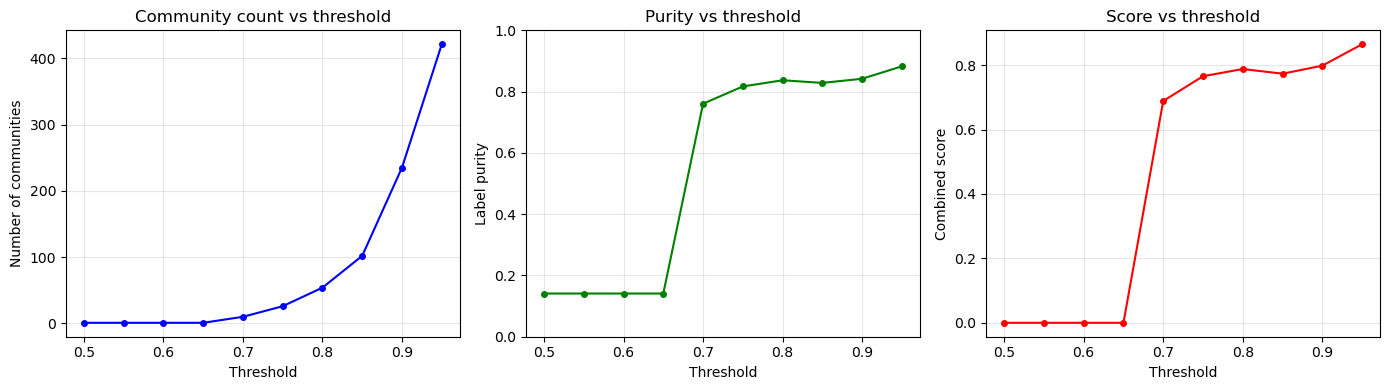

Saved: threshold_sweep.png


In [43]:
# Figure 1: Threshold sweep plot
if os.path.exists(RESULTS_DIR / 'threshold_sweep.csv'):
    sweep = pd.read_csv(RESULTS_DIR / 'threshold_sweep.csv')
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].plot(sweep['threshold'], sweep['n_comm'], 'bo-', markersize=4)
    axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Number of communities')
    axes[0].set_title('Community count vs threshold'); axes[0].grid(True, alpha=0.3)

    axes[1].plot(sweep['threshold'], sweep['purity'], 'go-', markersize=4)
    axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Label purity')
    axes[1].set_title('Purity vs threshold'); axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 1)

    axes[2].plot(sweep['threshold'], sweep['score'], 'ro-', markersize=4)
    axes[2].set_xlabel('Threshold'); axes[2].set_ylabel('Combined score')
    axes[2].set_title('Score vs threshold'); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'figures' / 'threshold_sweep.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: threshold_sweep.png")

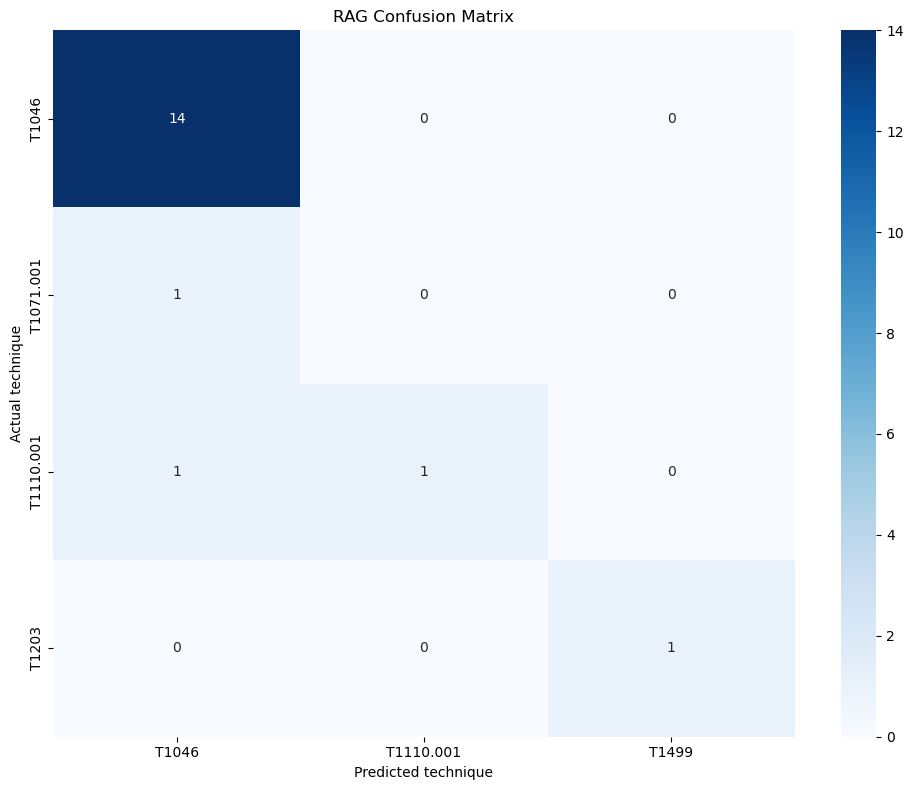

Saved: confusion_matrix.png


In [44]:
# Figure 2: Confusion matrix heatmap
if os.path.exists(RESULTS_DIR / 'rag_confusion_matrix.csv'):
    cm = pd.read_csv(RESULTS_DIR / 'rag_confusion_matrix.csv', index_col=0)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax)
    ax.set_xlabel('Predicted technique'); ax.set_ylabel('Actual technique')
    ax.set_title('RAG Confusion Matrix')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'figures' / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: confusion_matrix.png")

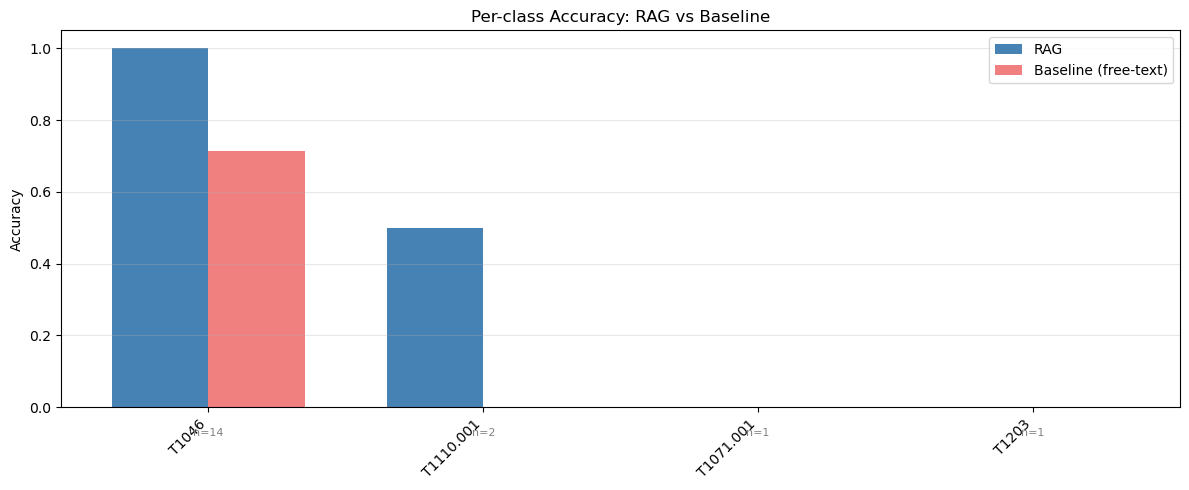

Saved: per_class_accuracy.png


In [45]:
# Figure 3: Per-class accuracy bar chart
if os.path.exists(RESULTS_DIR / 'rag_reports.csv'):
    reports = pd.read_csv(RESULTS_DIR / 'rag_reports.csv')

    by_gt = reports.groupby('ground_truth')
    class_summary = by_gt.agg(
        n=('rag_exact_match', 'count'),
        rag_acc=('rag_exact_match', 'mean'),
        base_acc=('base_exact_match', 'mean'),
    ).reset_index()
    class_summary.columns = ['Technique', 'N', 'RAG Accuracy', 'Baseline Accuracy']
    class_summary = class_summary.sort_values('N', ascending=False)

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(class_summary))
    w = 0.35
    ax.bar(x - w/2, class_summary['RAG Accuracy'].values, w, label='RAG', color='steelblue')
    ax.bar(x + w/2, class_summary['Baseline Accuracy'].values, w, label='Baseline (free-text)', color='lightcoral')
    ax.set_xticks(x)
    ax.set_xticklabels(class_summary['Technique'].values, rotation=45, ha='right')
    ax.set_ylabel('Accuracy')
    ax.set_title('Per-class Accuracy: RAG vs Baseline')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    for i, (_, row) in enumerate(class_summary.iterrows()):
        ax.text(i, -0.08, f'n={int(row["N"])}', ha='center', fontsize=8, color='gray')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'figures' / 'per_class_accuracy.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: per_class_accuracy.png")

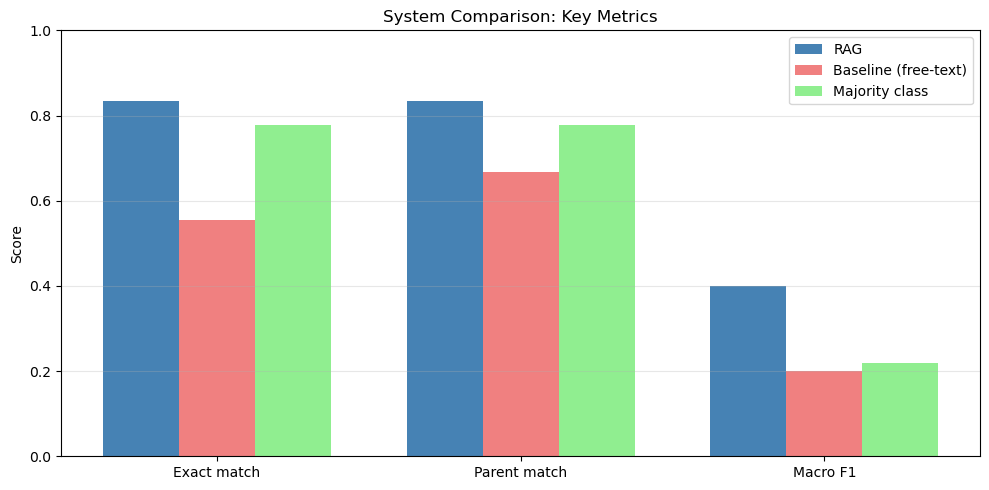

Saved: metrics_comparison.png
All figures saved to /home/amenadiel/RAG-Based-Incident-Reporting-on-SIEM-Log-Streams/results/cicids/mistral-nemo-12b/figures


In [46]:
# Figure 4: Metrics summary bar chart
if os.path.exists(RESULTS_DIR / 'rag_metrics.json'):
    with open(RESULTS_DIR / 'rag_metrics.json') as f:
        metrics = json.load(f)

    metric_names = ['Exact match', 'Parent match', 'Macro F1']
    rag_vals = [metrics.get('rag_exact_match_rate', 0),
                metrics.get('rag_parent_match_rate', 0),
                metrics.get('rag_macro_f1', 0)]
    base_vals = [metrics.get('baseline_exact_match_rate', 0),
                 metrics.get('baseline_parent_match_rate', 0),
                 metrics.get('baseline_macro_f1', 0)]
    majority_vals = [metrics.get('majority_class_accuracy', 0),
                     metrics.get('majority_class_accuracy', 0),
                     metrics.get('majority_macro_f1', 0)]

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(metric_names))
    w = 0.25
    ax.bar(x - w, rag_vals, w, label='RAG', color='steelblue')
    ax.bar(x, base_vals, w, label='Baseline (free-text)', color='lightcoral')
    ax.bar(x + w, majority_vals, w, label='Majority class', color='lightgreen')
    ax.set_xticks(x); ax.set_xticklabels(metric_names)
    ax.set_ylabel('Score'); ax.set_title('System Comparison: Key Metrics')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'figures' / 'metrics_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: metrics_comparison.png")

print(f"All figures saved to {RESULTS_DIR / 'figures'}")